# 01 - Exploratory Data Analysis

**Model objective:** classify task duration into duration buckets, such as Quick, Standard, Extended, or Long-Range, using relevant raw Jira ticket fields.

#### 01-01 Loading Raw Dataset


Load the raw Jira CSV and the plotting tools used throughout this notebook.

- **Pandas** handles tabular inspection and simple feature checks.
- **Matplotlib** provides lightweight plots for quick EDA.

The goal here is not to clean the dataset yet. This notebook identifies the main data-quality issues that the next notebook should handle.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

ticket_df = pd.read_csv('../jira_ticket_dataset.csv')

C:\Users\Omar\AppData\Local\Temp\ipykernel_34736\2962383518.py:4: DtypeWarning: Columns (0: customfield_12310921, 1: issuetype.subtask) have mixed types. Specify dtype option on import or set low_memory=False.
  ticket_df = pd.read_csv('../jira_ticket_dataset.csv')


#### 01-02 Dataset Shape Inspection

Start by inspecting the dataset's shape by:
- inspecting shape attribute, i.e, amount of columns and rows.
- calling info() method to retrieve basic info regarding columns and their name, types, null-count.
- inspecting dtypes attribute, i.e, what data types are present and what are their frequencies.
- calling sample() method by passing the amount of random sample data to retreive.

In [4]:
ticket_df.shape
ticket_df.info(memory_usage="deep")
ticket_df.value_counts()
ticket_df.sample(5, random_state=42)

<class 'pandas.DataFrame'>
RangeIndex: 1149323 entries, 0 to 1149322
Data columns (total 37 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   id                           1131224 non-null  float64
 1   key                          1149323 non-null  str    
 2   summary                      1131223 non-null  str    
 3   resolution.id                946655 non-null   float64
 4   resolution.description       928770 non-null   str    
 5   resolution.name              946655 non-null   str    
 6   priority.id                  1117464 non-null  float64
 7   priority.name                1117464 non-null  str    
 8   labels                       1131004 non-null  str    
 9   assignee                     780217 non-null   str    
 10  status.id                    1131224 non-null  float64
 11  status.description           1123393 non-null  str    
 12  status.name                  1131224 non-null  str   

,id,key,summary,resolution.id,resolution.description,resolution.name,priority.id,priority.name,labels,assignee,...,project.key,project.name,projectCategory.id,projectCategory.description,projectCategory.name,resolutiondate,watches.watchCount,created,updated,description
362921,12523653.0,SMXCOMP-905,ensure DONE status is set when cxf bc consumer...,1.0,A fix for this issue is checked into the tree ...,Fixed,3.0,Major,[],83fabe05,...,SMXCOMP,ServiceMix Components,10480.0,ServiceMix Enterprise Service Bus,ServiceMix,2011-09-20 07:03:49,0.0,2011-09-20 06:26:44,2011-09-20 07:03:49,this can prevent potential thread leak
431071,12722862.0,UIMA-3908,Review UIMA-AS support for running with embedd...,3.0,The problem is a duplicate of an existing issue.,Duplicate,3.0,Major,[],baaaf95c,...,UIMA,UIMA,10410.0,Apache UIMA,UIMA,2014-06-27 19:21:37,1.0,2014-06-20 22:39:19,2014-06-27 19:21:37,UIMA-AS needs to support embedded AMQ broker. ...
580054,13095949.0,LIVY-311,Set classpath in MiniCluster only when it is n...,1.0,A fix for this issue is checked into the tree ...,Fixed,3.0,Major,[],46920e83,...,LIVY,Livy,NaN,NaN,NaN,2017-02-16 01:19:18,1.0,2017-02-08 06:23:57,2017-02-16 01:19:18,NaN
164680,12704840.0,SPARK-859,Remove the executor count from the header,1.0,A fix for this issue is checked into the tree ...,Fixed,3.0,Major,[],3b73e472,...,SPARK,Spark,NaN,NaN,NaN,2013-08-06 21:57:27,1.0,2013-08-05 15:12:06,2013-08-06 21:57:27,NaN
994340,13585790.0,HUDI-7988,ListingBasedRollbackStrategy support logcompact,1.0,A fix for this issue is checked into the tree ...,Fixed,3.0,Major,['pull-request-available'],99fd0329,...,HUDI,Apache Hudi,NaN,NaN,NaN,2024-07-17 09:42:27,1.0,2024-07-15 08:06:35,2024-07-17 09:42:27,[1. https://github.com/apache/hudi/issues/1158...


#### 01-03 Raw Feature Inspection

Based on the dataframe inspection, the most relevant raw features to keep for initial modeling are:

- **summary**: ticket title or short task description
- **description**: longer issue details
- **priority.name**: priority category
- **labels**: assigned Jira labels
- **issuetype.description**: description of the issue type
- **issuetype.name**: issue type label
- **issuetype.subtask**: whether the issue is a subtask
- **resolutiondate**: timestamp used to derive duration
- **created**: timestamp used to derive duration

Some raw features will later be transformed into engineered model inputs:

- **summary** and **description** can become text-length or keyword features.
- **labels** can become a label-count feature.
- **resolutiondate** and **created** are used to derive the target duration.


In [5]:
# temporarily only use raw features that will be included in model training

raw_feature_columns = [
    "summary",
    "description",
    "priority.name",
    "labels",
    "issuetype.description",
    "issuetype.name",
    "issuetype.subtask",
    "resolutiondate",
    "created",
]


ticket_df = ticket_df[raw_feature_columns]

#### 01-04 Checking Null and Missing Values

Missing values are one of the first issues to inspect because they determine what can safely move into the cleaning notebook.

For this project, **created**, **resolutiondate**, and **summary** are non-negotiable fields:

- missing **created** or **resolutiondate** means `duration_days` cannot be calculated.
- missing **summary** removes a key text signal for model training.

The next plots show where missingness is concentrated and how much of the dataset is affected.


,missing_count,missing_percent
resolutiondate,202608,17.628465
description,123243,10.723095
priority.name,31859,2.771980
issuetype.description,19259,1.675682
labels,18319,1.593895
summary,18100,1.574840
issuetype.subtask,18099,1.574753
issuetype.name,18099,1.574753
created,18099,1.574753


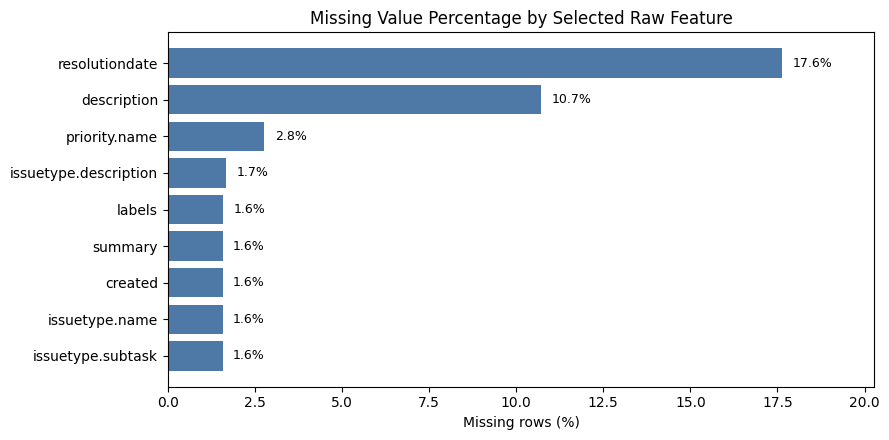

In [6]:
missing_table = pd.DataFrame({
    "missing_count": ticket_df.isna().sum(),
    "missing_percent": ticket_df.isna().mean() * 100
}).sort_values("missing_percent", ascending=True)

display(missing_table.sort_values("missing_percent", ascending=False))

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.barh(missing_table.index, missing_table["missing_percent"], color="#4E79A7")
ax.set_title("Missing Value Percentage by Selected Raw Feature")
ax.set_xlabel("Missing rows (%)")
ax.set_ylabel("")
ax.set_xlim(0, max(5, missing_table["missing_percent"].max() * 1.15))

for bar in bars:
    value = bar.get_width()
    if value > 0:
        ax.text(value + 0.3, bar.get_y() + bar.get_height() / 2, f"{value:.1f}%", va="center", fontsize=9)

plt.tight_layout()
plt.show()

**Rows with missing resolutiondate cannot be used for the first duration classification model because the target duration cannot be calculated.**

This chart highlights which selected raw features have the highest missing-value rates. A high missing percentage does not always mean a column is useless, but it does mean the cleaning notebook must handle that field deliberately.


#### 01-05 Timestamp Quality Check

Observe impossible values for dates such as:

- **No extreme date values, e.g <= 2000 or >= present day**
- **No resolution dates that precede created**

In [7]:
# convert dates to datetime

ticket_df["created"] = pd.to_datetime(
    ticket_df["created"],
    errors="coerce",
    utc=True
)

ticket_df["resolutiondate"] = pd.to_datetime(
    ticket_df["resolutiondate"],
    errors="coerce",
    utc=True
)

# check min / max of dates

print("Created Max: ", ticket_df["created"].max())
print("Created Min: ", ticket_df["created"].min()) # impossible value observed

print("Resolution Date Max: ", ticket_df["resolutiondate"].max())
print("Resolution Date Min: ", ticket_df["resolutiondate"].min())


# check impossible values

invalid_duration_count = (ticket_df["resolutiondate"] < ticket_df["created"]).sum()
invalid_duration_count

Created Max:  2024-11-06 15:59:21+00:00
Created Min:  2000-10-19 09:27:07+00:00
Resolution Date Max:  2025-03-04 04:00:30+00:00
Resolution Date Min:  2002-05-10 18:54:17+00:00


np.int64(18)

#### 01-06 Target Exploration

The main target feature is `duration_days`, calculated as:

`duration_days = resolutiondate - created`

The classes mapped to the output of the ML models will map according to the following ranges:

- *Quick: <= 3 days*
- *Standard: <= 7 days*
- *Extended: <= 21 days*
- *Long-range: > 21 days*

These initial bins are exploratory and may be revised after inspecting the duration distribution and class balance.

Let's look inspect some basic numeric data before graphing.

In [8]:
eda_df = ticket_df.copy()

eda_df["duration_days"] = (eda_df["resolutiondate"] - eda_df["created"]).dt.total_seconds() / 86400
eda_df.describe()

,duration_days
count,946426.000000
mean,203.954379
std,520.375742
min,-0.372951
25%,1.049771
50%,11.915307
75%,112.017925
max,8001.517257


In [9]:
eda_df["duration_days"].quantile([
    0.00,
    0.01,
    0.05,
    0.10,
    0.25,
    0.50,
    0.75,
    0.90,
    0.95,
    0.99,
    1.00
])

0.00      -0.372951
0.01       0.000868
0.05       0.009699
0.10       0.059016
0.25       1.049771
0.50      11.915307
0.75     112.017925
0.90     623.853941
0.95    1199.511267
0.99    2694.205712
1.00    8001.517257
Name: duration_days, dtype: float64

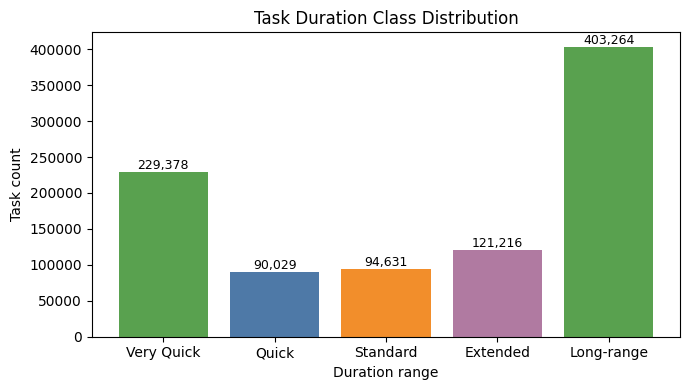

In [10]:
# Basic cleaning only for visualization in this EDA notebook.
# The formal cleaning steps are handled in 02_data_cleaning.ipynb.

cleaned_df = ticket_df.drop_duplicates()
cleaned_df = cleaned_df.dropna(subset=["created", "resolutiondate", "summary"]).copy()



cleaned_df["created"] = pd.to_datetime(cleaned_df["created"], errors="coerce")
cleaned_df["resolutiondate"] = pd.to_datetime(cleaned_df["resolutiondate"], errors="coerce")

cleaned_df["duration_days"] = (cleaned_df["resolutiondate"] - cleaned_df["created"]).dt.total_seconds() / (60 * 60 * 24)
cleaned_df = cleaned_df[cleaned_df["duration_days"].notna() & (cleaned_df["duration_days"] >= 0)]

def duration_range(days):
    if days <= 1:
        return "Very Quick"
    if days <= 3:
        return "Quick"
    if days <= 7:
        return "Standard"
    if days <= 21:
        return "Extended"
    return "Long-range"

duration_order = ["Very Quick", "Quick", "Standard", "Extended", "Long-range"]
cleaned_df["duration_range"] = cleaned_df["duration_days"].apply(duration_range)
duration_counts = cleaned_df["duration_range"].value_counts().reindex(duration_order)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(duration_counts.index, duration_counts.values, color=["#59A14F", "#4E79A7", "#F28E2B", "#B07AA1"])
ax.set_title("Task Duration Class Distribution")
ax.set_xlabel("Duration range")
ax.set_ylabel("Task count")

# adds floating max values

for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{int(bar.get_height()):,}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()


As observed, there exists extreme values at both ends of the range bins.

Let's take a closer look at how the frequencies are distributed among the Very Quick and Long-range classes.

##### '*Very Quick*' Values Rate Of Change

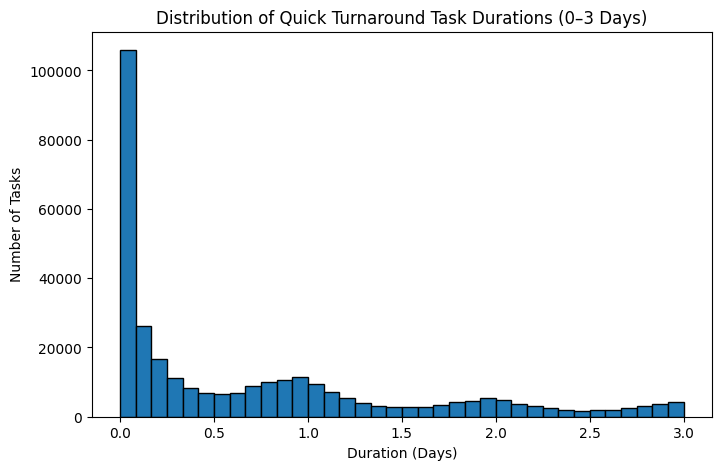

In [14]:
quick_df = cleaned_df[
    (cleaned_df["duration_days"] >= 0) &
    (cleaned_df["duration_days"] <= 3)
]

plt.figure(figsize=(8, 5))

# each rectangle represents 2 hrs

plt.hist(quick_df["duration_days"], bins=36, edgecolor="black")

plt.title("Distribution of Quick Turnaround Task Durations (0–3 Days)")
plt.xlabel("Duration (Days)")
plt.ylabel("Number of Tasks")

plt.show()


As seen above, we can conclude that the first 2 hours positvely skew significantly.

Therefore we might consider elimating the first 2 hours to balance the distribution and avoid overfitting the model. 

##### '*Long-term*' Rate Of Change

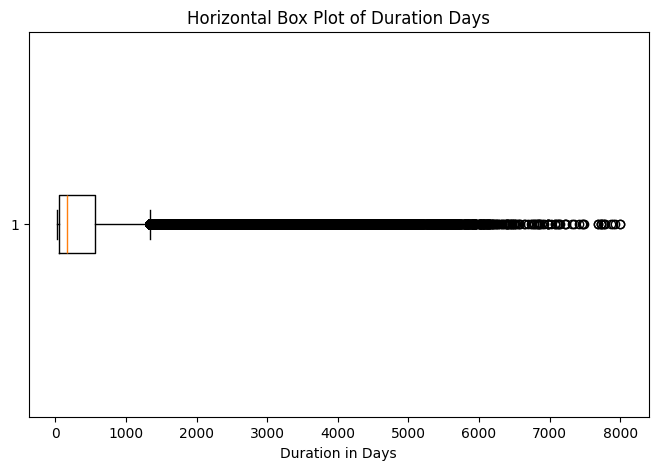

In [15]:
quick_df = cleaned_df.loc[cleaned_df["duration_days"] > 21, "duration_days"].dropna()

plt.figure(figsize=(8, 5))
plt.boxplot(quick_df, vert=False)
plt.title("Horizontal Box Plot of Duration Days")
plt.xlabel("Duration in Days")
plt.show()

A boxplot is useful in identifying outliers since it uses an IQR (Inter Quartile Range), the box and the point before it represent 75% of the data and therefore it seems the majority of the 'Long-range' tasks fall between 22 days and more or less than 500 days.